# Marker × marker similarity clustermap + per-cluster driver analysis

Two analyses on a shared TF-IDF-normalized marker × geneKO distinctiveness matrix:

1. **Marker × marker Pearson similarity clustermap.** Hierarchically-clustered marker × marker Pearson correlation heatmap. TF-IDF reweighting highlights features hit by few markers, surfacing each marker's unique signal. Rows + columns share the same average-linkage tree on (1 − Pearson r) of similarity rows; a per-marker organelle color strip flanks both axes.
2. **Per-cluster driver analysis (Fig 3D).** Five manually defined marker clusters are scored gene-by-gene with a Cohen-d-like specificity metric. Top drivers are visualized as a vertical overview heatmap, and each cluster's top-25/50/100 drivers are tested for enrichment in GO BP/CC/MF, Reactome, and KEGG via gseapy.enrichr (with the 1,000-gene screen library as background). Enrichment outputs are compiled into per-cluster Excel workbooks (15 sheets each).

All outputs land in `output/figure_3/`. PNG (180 dpi), SVG, and PDF figures preserve text as editable text for downstream figure assembly in Adobe Illustrator.

## Imports

In [1]:
import re
import time
from pathlib import Path

import gseapy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import linkage as _linkage
from scipy.spatial.distance import squareform as _squareform

# Illustrator-friendly text exports
plt.rcParams["pdf.fonttype"] = 42      # TrueType in PDF
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"  # SVG text as <text> elements

FIGURES_DIR = Path("../../output/figure_3")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## CSV paths

- `DIST_RAW_CSV` — per-gene × per-reporter distinctiveness matrix (genes × reporters). Four 4i markers are dropped at load.
- `METADATA_CSV` — per-marker short name, organelle category, color, and category rank, produced by `data_preprocessing/marker_organelle_metadata.py`.

**Before public release**, replace the icd.fast.ops path with download instructions (or a pointer to the public dataset) and update the constants to match the released layout.

In [2]:
DIST_RAW_CSV = "/hpc/projects/icd.fast.ops/organelle_attribution/pca_optimized_v0.3/cell_dino/zscore_per_exp/paper_v1/with_cp/with_4i/all_livecell/fixed_80%/cosine/second_pca_consensus/plots/marker_overlay/gene_reporter_distinctiveness_raw.csv"
METADATA_CSV = "../../data_preprocessing/data/marker_organelle_metadata.csv"

EXCLUDED_MARKERS = {"NFkB (4i)", "RSP6 (4i)", "Rb (4i)", "gH2AX (4i)"}

## Load distinctiveness matrix and marker metadata

Distinctiveness CSV is genes × reporters; transpose to markers × geneKOs, drop the `all_combined` reference column, drop excluded markers. The metadata CSV is keyed by full marker name and carries `short_name`, `category`, `color`, and `category_rank`.

In [3]:
raw = pd.read_csv(DIST_RAW_CSV, index_col=0)
raw = raw.drop(columns=[c for c in raw.columns if c == "all_combined"], errors="ignore")
M = raw.transpose()

excl = {e.lower() for e in EXCLUDED_MARKERS}
M = M.loc[[m for m in M.index if str(m).lower() not in excl]]

meta_df = pd.read_csv(METADATA_CSV)

print(f"markers × geneKOs: {M.shape}")
print(f"metadata rows:     {len(meta_df)}")

markers × geneKOs: (53, 1001)
metadata rows:     53


## TF-IDF normalize, then Pearson similarity

- **TF-IDF**: `tf = value / row_sum`, `idf = log(N / (#markers above column mean))`. Downweights features many markers hit (low IDF) and amplifies rare-hit features.
- **Pearson r**: marker × marker correlation across the normalized feature dimension.

In [4]:
# TF-IDF
safe_row = M.sum(axis=1).replace(0, np.nan)
tf = M.div(safe_row, axis=0).fillna(0.0)
df = (M > M.mean(axis=0)).sum(axis=0).replace(0, np.nan)
idf = np.log((M.shape[0] + 1) / (df + 1))
M_norm = tf.mul(idf, axis=1).fillna(0.0)

# Pearson marker × marker similarity
sim = M_norm.transpose().corr(method="pearson")
print(f"similarity shape: {sim.shape}")

similarity shape: (53, 53)


## Clustered heatmap

Average-linkage hierarchical clustering on (1 − Pearson r) of similarity rows; same tree on rows and columns. Color scale floored at 0 so negative correlations clip to white, top anchored at the max off-diagonal value. Organelle color strip on both axes; `*` flags fixed-sample (Cell Painting / 4i) markers.

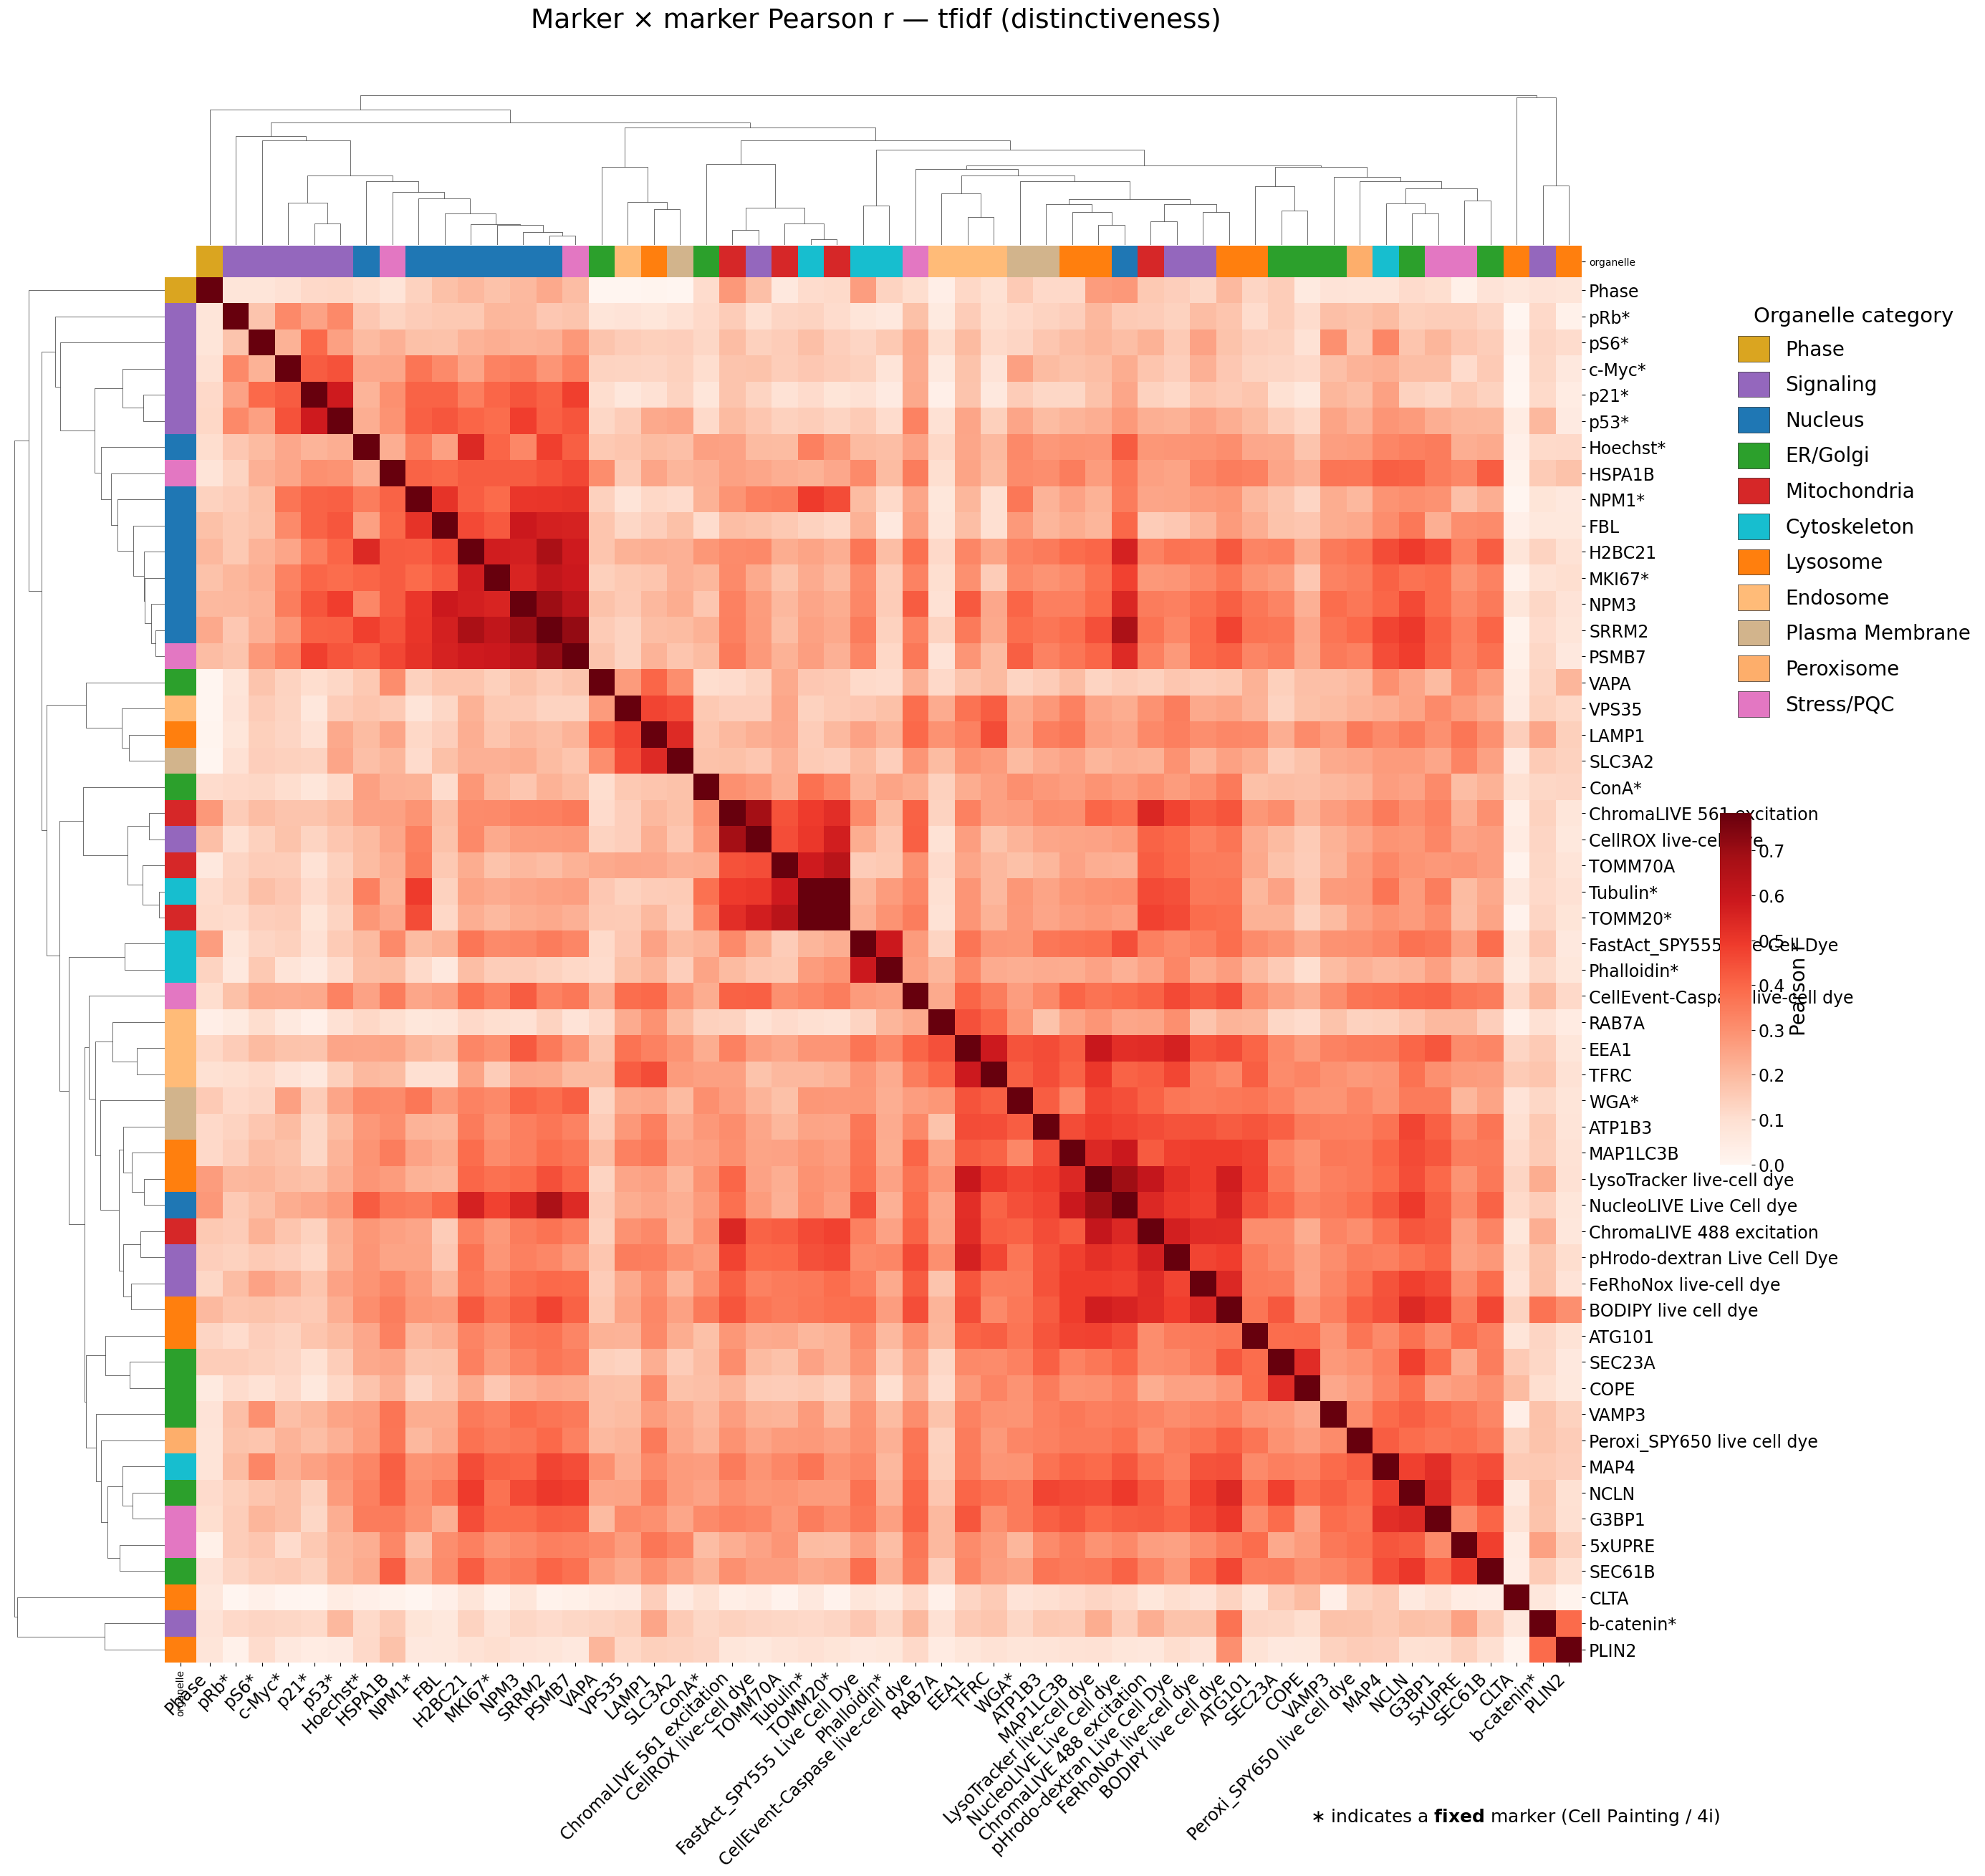

In [5]:
markers = list(sim.index)
marker_meta = meta_df.set_index("marker").loc[markers]
short = marker_meta["short_name"].tolist()

sim_short = sim.copy()
sim_short.index = short
sim_short.columns = short

# Per-marker organelle category color (Series indexed by short name)
cat_short = pd.Series(marker_meta["color"].values, index=short, name="organelle")

# Legend: one entry per category that appears, sorted by display rank
legend_df = (
    marker_meta[["category", "color", "category_rank"]]
    .drop_duplicates(subset="category")
    .sort_values("category_rank")
)
legend_items = list(zip(legend_df["category"], legend_df["color"]))

# Symmetric linkage on (1 - Pearson r) of similarity rows
rows = sim.fillna(0.0).to_numpy(dtype=float)
corr = np.corrcoef(rows)
np.fill_diagonal(corr, 1.0)
dist = np.clip(1.0 - corr, 0.0, None)
dist = (dist + dist.T) / 2.0
np.fill_diagonal(dist, 0.0)
Z = _linkage(_squareform(dist, checks=False), method="average")

# Floor color scale at 0; top = max off-diagonal
sim_arr = sim.to_numpy()
off_diag = sim_arr[~np.eye(sim_arr.shape[0], dtype=bool)]
off_diag = off_diag[np.isfinite(off_diag)]
vmax_use = float(off_diag.max()) if off_diag.size else 1.0
vmin_use = 0.0

side = max(20, len(markers) * 0.35 + 6)
g = sns.clustermap(
    sim_short,
    row_linkage=Z, col_linkage=Z,
    row_cluster=True, col_cluster=True,
    cmap="Reds", vmin=vmin_use, vmax=vmax_use, center=None,
    row_colors=cat_short, col_colors=cat_short,
    figsize=(side, side),
    dendrogram_ratio=(0.10, 0.10),
    colors_ratio=0.02,
    xticklabels=True, yticklabels=True,
    cbar_pos=(0.98, 0.5, 0.018, 0.16),
)
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", va="top", fontsize=17)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=17)
if g.cax is not None:
    g.cax.set_ylabel("Pearson r", fontsize=20)
    g.cax.tick_params(labelsize=17)

legend_handles = [
    Patch(facecolor=clr, edgecolor="black", linewidth=0.4, label=cat)
    for cat, clr in legend_items
]
legend = g.fig.legend(
    handles=legend_handles, loc="upper left",
    bbox_to_anchor=(0.98, 0.88), frameon=False, fontsize=20,
    title="Organelle category", title_fontsize=21,
    handlelength=1.6, handleheight=1.6, borderaxespad=0.5,
    labelspacing=0.5,
)
g.fig.canvas.draw()
leg_bbox = legend.get_window_extent().transformed(g.fig.transFigure.inverted())
cbar_h = 0.20
cbar_y = max(leg_bbox.y0 - cbar_h - 0.05, 0.02)
if g.cax is not None:
    g.cax.set_position([0.98, cbar_y, 0.018, cbar_h])

g.fig.suptitle("Marker × marker Pearson r — tfidf (distinctiveness)", fontsize=27, y=1.04)
g.fig.text(
    0.98, 0.005,
    r"$\ast$ indicates a $\mathbf{fixed}$ marker (Cell Painting / 4i)",
    ha="right", va="bottom", fontsize=18,
)

g.fig.savefig(FIGURES_DIR / "clustermap_distinctiveness_pearson_tfidf.svg", bbox_inches="tight")
plt.show()

## Cluster definitions

Five manually defined marker clusters, guided by hierarchical clustering of the marker × marker Pearson correlation matrix and prior biology. Marker names must match `M_norm.index` exactly. A `sanitize_label` helper collapses spaces, slashes, and other non-alphanumeric characters to `_` so the descriptive dict keys can be reused as filename fragments.

In [ ]:
CLUSTERS = {
    "Nucleus & nucleolus markers": [
        "nucleoli, NPM1 (cp)",
        "nucleolus-DFC, FBL",
        "chromatin, H2BC21",
        "cell proliferation marker, MKI67",
        "nucleolus-GC, NPM3",
        "nuclear speckles, SRRM2",
        "proteasome, PSMB7",
    ],
    "Organellar markers": [
        "ER/golgi bridge, VAPA",
        "endosome, VPS35",
        "lysosome, LAMP1",
        "plasma membrane, SLC3A2",
    ],
    "Mitochondrial markers + tubulin": [
        "mitochondria, ChromaLIVE 561 excitation",
        "oxidative stress, CellROX live-cell dye",
        "mitochondria, TOMM70A",
        "microtubules, Tubulin (cp)",
        "mitochondria, TOMM20 (cp)",
    ],
    "Actin markers": [
        "actin filament, FastAct_SPY555 Live Cell Dye",
        "f-actin, Phalloidin (cp)",
    ],
    "ER/Golgi markers": [
        "ER/Golgi COP-II, SEC23A",
        "ER/Golgi, COPE",
    ],
}


def sanitize_label(label):
    """Collapse non-alphanumeric runs to '_' so cluster labels are safe in filenames."""
    return re.sub(r"[^A-Za-z0-9]+", "_", label).strip("_")


# Tunable parameters
TOP_N_SIZES = [25, 50, 100]   # driver-list sizes for enrichment
GENE_SETS = [
    "GO_Biological_Process_2023",
    "GO_Cellular_Component_2023",
    "GO_Molecular_Function_2023",
    "Reactome_2022",
    "KEGG_2021_Human",
]
BACKGROUND = M_norm.columns.tolist()  # the screen's 1,000-gene library

# Validate marker names
for label, members in CLUSTERS.items():
    missing = [m for m in members if m not in M_norm.index]
    if missing:
        raise ValueError(f"cluster '{label}' has unknown markers: {missing}")
print(f"All {len(CLUSTERS)} clusters validated. {len(BACKGROUND)}-gene background.")
for label, members in CLUSTERS.items():
    print(f"  {label:34s} n={len(members)}  ->  {sanitize_label(label)}")

## Per-cluster Cohen-d-like specificity scoring

For each cluster c and each gene g, compute the cluster-specificity score

$$ d(c, g) = \frac{\bar X_{m\in c, g} - \bar X_{m\notin c, g}}{s_{\text{pooled}}} $$

with pooled SD $s_{\text{pooled}} = \sqrt{((n_{\text{in}}-1)\sigma^2_{\text{in}} + (n_{\text{out}}-1)\sigma^2_{\text{out}})/(n_{\text{in}}+n_{\text{out}}-2)}$ and sample standard deviations (ddof = 1). Scale-free; ranks genes by cluster-vs-background mean shift in pooled-SD units.

In [ ]:
def cluster_cohen_d(cluster_members):
    """Per-gene Cohen-d-like specificity for one cluster."""
    Xi = M_norm.loc[cluster_members]
    Xo = M_norm.drop(index=cluster_members)
    n_in, n_out = len(Xi), len(Xo)
    std_in = Xi.std(axis=0, ddof=1)
    std_out = Xo.std(axis=0, ddof=1)
    pooled = np.sqrt(
        ((n_in - 1) * std_in ** 2 + (n_out - 1) * std_out ** 2) / (n_in + n_out - 2)
    )
    return (Xi.mean(axis=0) - Xo.mean(axis=0)) / pooled.replace(0, np.nan)


# Compute once; reused by both the heatmap and the enrichment sections below.
cluster_d = {label: cluster_cohen_d(members) for label, members in CLUSTERS.items()}
print("Cohen-d Series computed for all", len(cluster_d), "clusters.")

## Top-50 driver gene overview heatmap

Vertical heatmap of the union of the top-50 cluster-specific driver genes per cluster (ranked by the Cohen-d score from section 3), one column per cluster. Genes are grouped into per-cluster blocks in the row order of `CLUSTERS`, with horizontal separators between blocks; the colorbar is capped at d = `VMAX_CAP_LOCAL` (default 5) so small-n and large-n clusters remain visually comparable. Cells with d < 0.05 are masked. Gene labels are omitted because the row count (~200–250) is too dense to read.

In [ ]:
# Top-50 driver-gene overview heatmap — vertical orientation.
# Union of top-50 per cluster (~200–250 genes total). Gene names are
# omitted since they would be illegible at this row count.

TOP_N_50 = 50
VMAX_CAP_LOCAL = 5.0   # Cohen-d cap for THIS cell only; raise (e.g. 10) to
                       # show more of the tail, lower (e.g. 3) to saturate
                       # earlier and emphasize moderate-effect genes.

# Build deduplicated top-50 union, preserving cluster-block order
gene_order_50 = []
block_boundaries_50 = [0]
for label in CLUSTERS:
    top = (
        cluster_d[label]
        .sort_values(ascending=False)
        .head(TOP_N_50)
        .index.tolist()
    )
    new_genes = [g for g in top if g not in gene_order_50]
    gene_order_50.extend(new_genes)
    block_boundaries_50.append(len(gene_order_50))

# Cluster × gene matrix, then transpose for vertical orientation (genes as rows)
M50 = pd.DataFrame(
    {label: cluster_d[label].loc[gene_order_50] for label in CLUSTERS}
).T
Mv50 = M50.T

print(
    f"Gene-union size: {len(gene_order_50)} "
    f"(no overlaps means {len(CLUSTERS) * TOP_N_50})"
)
print(f"Block boundaries (row indices): {block_boundaries_50}")
print(f"Matrix shape (genes × clusters): {Mv50.shape}")

mask_v50 = Mv50 < 0.05

fig, ax = plt.subplots(
    figsize=(0.2 * Mv50.shape[1] + 3, max(8.0, 0.04 * Mv50.shape[0] + 2))
)
sns.heatmap(
    Mv50,
    mask=mask_v50,
    cmap="Reds",
    vmin=0,
    vmax=VMAX_CAP_LOCAL,
    annot=False,
    linewidths=0,
    cbar_kws={"label": "Cohen-d", "shrink": 0.4},
    ax=ax,
)
cbar = ax.collections[0].colorbar
tick_vals = list(range(0, int(VMAX_CAP_LOCAL) + 1))
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([str(t) for t in tick_vals[:-1]] + [f"≥{int(VMAX_CAP_LOCAL)}"])

# Horizontal separators between the cluster-blocks of genes
for b in block_boundaries_50[1:-1]:
    ax.axhline(b, color="#444", lw=0.8)

ax.set_title(
    f"Top-{TOP_N_50} cluster-specific drivers — Cohen-d across all clusters",
    fontsize=11,
)
ax.set_xlabel("cluster", fontsize=10)
ax.set_ylabel(f"gene KOs (top-{TOP_N_50} union, grouped by source cluster)", fontsize=10)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticks([])   # gene names omitted — too many rows to read

fig.tight_layout()
base_v50 = FIGURES_DIR / "Fig_3D_top50_drivers_overview_vertical"
fig.savefig(base_v50.with_suffix(".png"), dpi=180, bbox_inches="tight")
fig.savefig(base_v50.with_suffix(".svg"), bbox_inches="tight")
fig.savefig(base_v50.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
print("saved to", base_v50.with_suffix(".png"))

## Functional enrichment (Enrichr via gseapy)

For each cluster and each of three driver-list sizes (top-25, top-50, top-100), run gseapy.enrichr against five libraries: GO_BP_2023, GO_CC_2023, GO_MF_2023, Reactome_2022, KEGG_2021_Human. The screen's own 1,000-gene library is used as the background (rather than the human genome) so that the over-representation test is anchored to the actual sampling universe and doesn't over-inflate broadly studied pathways.

Each library is queried individually (gseapy 1.1.x mislabels results when a list of libraries is passed jointly with a custom background) and re-labeled before concatenation. Per-library raw subfolders and concatenated per-(cluster, list-size) CSVs are written, plus a summary table of significant-term counts.

Runtime: 5 clusters × 3 list sizes × 5 libraries = 75 Enrichr API calls; ~2 minutes.

In [ ]:
def run_enrichr(gene_list, cluster_label, top_n):
    """Enrichr per-library call + concat. Each library queried individually with
    the custom background; the returned Gene_set column is rewritten to the
    correct library name (workaround for gseapy 1.1.x mis-labeling).
    Writes per-library subfolder + concatenated CSV to FIGURES_DIR.
    """
    tag = f"top{top_n}"
    safe_label = sanitize_label(cluster_label)
    frames = []
    for gs in GENE_SETS:
        out_subdir = FIGURES_DIR / f"enrichr_{tag}_{safe_label}" / gs
        res = gseapy.enrichr(
            gene_list=gene_list,
            gene_sets=gs,
            background=BACKGROUND,
            organism="human",
            outdir=str(out_subdir),
            no_plot=True,
        )
        df = res.results.copy()
        df["Gene_set"] = gs  # force correct label
        frames.append(df)
    df = pd.concat(frames, ignore_index=True)
    df.to_csv(FIGURES_DIR / f"enrichment_{tag}_{safe_label}.csv", index=False)
    return df

In [ ]:
summary = []
t0 = time.time()

for label, members in CLUSTERS.items():
    print(f"\n=== {label}  (n={len(members)}) ===")
    d = cluster_d[label].sort_values(ascending=False)
    for n in TOP_N_SIZES:
        gene_list = d.head(n).index.tolist()
        t_start = time.time()
        df = run_enrichr(gene_list, label, n)
        n_sig = int((df["Adjusted P-value"] < 0.05).sum())
        elapsed = time.time() - t_start
        print(f"  top-{n:>3d}  ({len(gene_list)} genes)  →  {n_sig:>3d} sig terms  [{elapsed:.1f}s]")
        summary.append({"cluster": label, "top_n": n, "n_sig_terms": n_sig})

print(f"\nTotal time: {time.time() - t0:.1f}s")

# Pivot to a cluster × list-size table and save.
summary_df = (
    pd.DataFrame(summary)
    .pivot(index="cluster", columns="top_n", values="n_sig_terms")
    .reindex(index=list(CLUSTERS))   # preserve CLUSTERS insertion order
)
summary_df.columns = [f"top-{n} (Adj p<0.05)" for n in summary_df.columns]
summary_csv = FIGURES_DIR / "enrichment_summary.csv"
summary_df.to_csv(summary_csv)
print(f"\nsummary table saved to {summary_csv}")
print("\n=== summary: number of significant enriched terms per (cluster, list size) ===")
print(summary_df.to_string())

## Compile enrichment results into per-cluster Excel files

For each marker cluster, build a single `enrichment_<cluster>.xlsx` with **15 sheets** — five pathway/ontology libraries (GO_BP / GO_CC / GO_MF / Reactome / KEGG) × three driver-list sizes (top-25 / top-50 / top-100). Sheets are named `GOBP_top25`, `Reactome_top50`, `KEGG_top100`, etc. Within each sheet, terms are sorted by Adjusted P-value (ascending) and the redundant `Gene_set` column is dropped (the sheet name already encodes it).

Re-uses the per-(cluster, list-size) CSVs written by the enrichment section above, so re-run that section if you change `CLUSTERS` or `GENE_SETS`. Sheets where the corresponding library is missing from the CSV (e.g. you skipped re-running the enrichment section after adding GO_MF) are populated with a placeholder row pointing back here.

In [ ]:
# One Excel workbook per cluster, 15 sheets each
# (GOBP/GOCC/GOMF/Reactome/KEGG × top25/top50/top100).
# Reads the per-(cluster, list-size) CSVs written by the enrichment section above, so re-run that section
# if you changed CLUSTERS or GENE_SETS.

LIBRARIES = {
    "GOBP":     "GO_Biological_Process_2023",
    "GOCC":     "GO_Cellular_Component_2023",
    "GOMF":     "GO_Molecular_Function_2023",
    "Reactome": "Reactome_2022",
    "KEGG":     "KEGG_2021_Human",
}

print("Compiling enrichment results into per-cluster Excel files:")
for label in CLUSTERS:
    safe_label = sanitize_label(label)
    xlsx_path = FIGURES_DIR / f"enrichment_{safe_label}.xlsx"

    n_sheets = 0
    n_warnings = 0
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        for n in TOP_N_SIZES:
            csv = FIGURES_DIR / f"enrichment_top{n}_{safe_label}.csv"
            if not csv.exists():
                print(f"  ! missing input: {csv.name}  (run section 5 first)")
                n_warnings += 1
                continue
            df = pd.read_csv(csv)
            for tag, lib in LIBRARIES.items():
                sheet_name = f"{tag}_top{n}"
                sub = df[df["Gene_set"] == lib].drop(columns=["Gene_set"])
                if sub.empty:
                    pd.DataFrame(
                        {"note": [f"no rows for {lib} in {csv.name} — re-run that section to query this library"]}
                    ).to_excel(writer, sheet_name=sheet_name, index=False)
                    n_warnings += 1
                else:
                    sub = sub.sort_values("Adjusted P-value").reset_index(drop=True)
                    sub.to_excel(writer, sheet_name=sheet_name, index=False)
                n_sheets += 1
    tail = f"  ({n_warnings} sheets empty / missing)" if n_warnings else ""
    print(f"  {label:34s} → {xlsx_path.name}  ({n_sheets} sheets){tail}")